In [5]:
# Import Required Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [6]:
# Load the Built-in Dataset
dataset, info = tfds.load("oxford_iiit_pet", with_info=True)

train_data = dataset['train']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.MJPNZ1_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.MJPNZ1_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [7]:
# Define Image Size and Preprocessing Function
IMG_SIZE = 128
BATCH_SIZE = 16

def preprocess(data):
    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    mask = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE))
    mask = tf.cast(mask == 1, tf.float32)

    return image, mask

In [8]:
# Apply Preprocessing and Prepare Dataset
train_dataset = train_data.map(preprocess)
train_dataset = train_dataset.batch(BATCH_SIZE).take(100)

In [9]:
# Build a Simplified U-Net Model
inputs = tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3))

# Encoder
c1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
p1 = tf.keras.layers.MaxPooling2D()(c1)

c2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
p2 = tf.keras.layers.MaxPooling2D()(c2)

# Bottleneck
b = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

# Decoder
u1 = tf.keras.layers.UpSampling2D()(b)
c3 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

u2 = tf.keras.layers.UpSampling2D()(c3)
c4 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c4)

model = tf.keras.Model(inputs, outputs)

In [10]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the Model
model.fit(train_dataset, epochs=3)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.6844 - loss: 0.6006
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.7061 - loss: 0.5023
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - accuracy: 0.7424 - loss: 0.4886


In [12]:
# Predict Segmentation Mask
for images, masks in train_dataset.take(1):
    predictions = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step


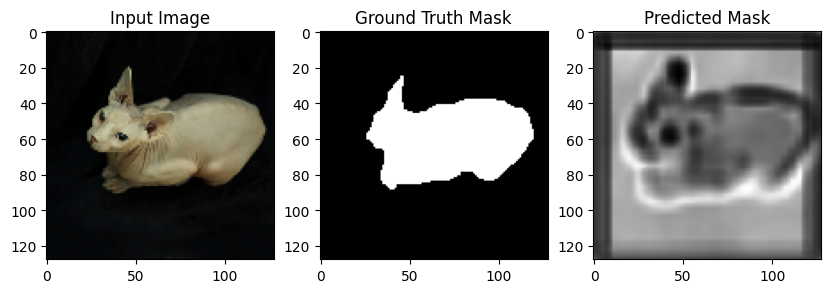

In [13]:
# Visualize Results
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(images[0])

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(masks[0][:,:,0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(predictions[0][:,:,0], cmap='gray')

plt.show()